In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw



In [10]:
def train_model(model, optimizer, criterion, epochs):
    train_loss, train_acc = [], []

    for epoch in range(epochs):
        model.train()
        correct, total, running_loss = 0, 0, 0

        for x, y in train_loader:
            x = x.to(device)   # 🔥 move data to GPU
            y = y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        train_loss.append(running_loss / len(train_loader))
        train_acc.append(correct / total)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Loss: {train_loss[-1]:.4f} | "
              f"Acc: {train_acc[-1]*100:.2f}%")

    return train_loss, train_acc


In [11]:
def test_model(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)   # 🔥 move data to GPU
            y = y.to(device)

            out = model(x)
            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total


In [12]:
class CNN(nn.Module):
    def __init__(self, activation, use_bn=False, dropout=0.25):
        super().__init__()

        self.act = activation
        self.use_bn = use_bn

        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout(dropout)

        if use_bn:
            self.bn1 = nn.BatchNorm2d(32)
            self.bn2 = nn.BatchNorm2d(64)
            self.bn_fc = nn.BatchNorm1d(128)

        self.fc1 = nn.Linear(64*12*12, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        if self.use_bn: x = self.bn1(x)
        x = self.act(x)

        x = self.conv2(x)
        if self.use_bn: x = self.bn2(x)
        x = self.act(x)

        x = self.pool(x)
        x = self.drop(x)

        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        if self.use_bn: x = self.bn_fc(x)
        x = self.act(x)

        return self.fc2(x)


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


# Task 1: Activation Function Challenge
     Experiment 1: Sigmoid + SGD

In [14]:
model = CNN(nn.Sigmoid()).to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

loss_sig, acc_sig = train_model(model, optimizer, criterion, epochs=10)
test_sig = test_model(model)

print("Test Accuracy (Sigmoid + SGD):", test_sig)

Epoch 1/10 | Loss: 2.2995 | Acc: 11.71%
Epoch 2/10 | Loss: 2.2606 | Acc: 21.44%
Epoch 3/10 | Loss: 1.7060 | Acc: 61.25%
Epoch 4/10 | Loss: 0.7909 | Acc: 81.19%
Epoch 5/10 | Loss: 0.5294 | Acc: 86.29%
Epoch 6/10 | Loss: 0.4341 | Acc: 88.05%
Epoch 7/10 | Loss: 0.3850 | Acc: 89.06%
Epoch 8/10 | Loss: 0.3545 | Acc: 89.79%
Epoch 9/10 | Loss: 0.3320 | Acc: 90.22%
Epoch 10/10 | Loss: 0.3142 | Acc: 90.68%
Test Accuracy (Sigmoid + SGD): 0.9169


In [16]:
model = CNN(nn.Tanh()).to(device)          # 🔥 move model to GPU
optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

loss_tanh, acc_tanh = train_model(
    model,
    optimizer,
    criterion,
    epochs=10
)

test_tanh = test_model(model)

print("Test Accuracy (Tanh + SGD):", test_tanh)


Epoch 1/10 | Loss: 0.4871 | Acc: 87.91%
Epoch 2/10 | Loss: 0.2384 | Acc: 93.11%
Epoch 3/10 | Loss: 0.1853 | Acc: 94.69%
Epoch 4/10 | Loss: 0.1510 | Acc: 95.68%
Epoch 5/10 | Loss: 0.1268 | Acc: 96.41%
Epoch 6/10 | Loss: 0.1079 | Acc: 97.01%
Epoch 7/10 | Loss: 0.0934 | Acc: 97.41%
Epoch 8/10 | Loss: 0.0821 | Acc: 97.79%
Epoch 9/10 | Loss: 0.0733 | Acc: 98.04%
Epoch 10/10 | Loss: 0.0664 | Acc: 98.25%
Test Accuracy (Tanh + SGD): 0.9798


In [17]:
model = CNN(nn.ReLU()).to(device)          # 🔥 move model to GPU
optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

loss_relu, acc_relu = train_model(
    model,
    optimizer,
    criterion,
    epochs=10
)

test_relu = test_model(model)

print("Test Accuracy (ReLU + SGD):", test_relu)


Epoch 1/10 | Loss: 0.4440 | Acc: 87.33%
Epoch 2/10 | Loss: 0.1856 | Acc: 94.40%
Epoch 3/10 | Loss: 0.1313 | Acc: 96.11%
Epoch 4/10 | Loss: 0.1044 | Acc: 96.77%
Epoch 5/10 | Loss: 0.0832 | Acc: 97.47%
Epoch 6/10 | Loss: 0.0701 | Acc: 97.81%
Epoch 7/10 | Loss: 0.0595 | Acc: 98.19%
Epoch 8/10 | Loss: 0.0512 | Acc: 98.46%
Epoch 9/10 | Loss: 0.0456 | Acc: 98.59%
Epoch 10/10 | Loss: 0.0411 | Acc: 98.77%
Test Accuracy (ReLU + SGD): 0.985


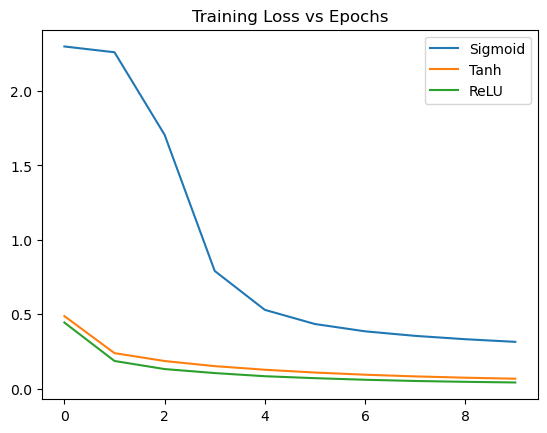

In [18]:
plt.plot(loss_sig, label="Sigmoid")
plt.plot(loss_tanh, label="Tanh")
plt.plot(loss_relu, label="ReLU")
plt.legend()
plt.title("Training Loss vs Epochs")
plt.show()


# Observed Results

    From the training loss curves obtained using Sigmoid, Tanh, and ReLU activation functions, the following patterns were observed:
    
    The model using Sigmoid activation showed slow convergence and relatively higher training loss across epochs.
    
    The Tanh activation performed better than Sigmoid, with faster convergence and lower loss, but still converged slower compared to ReLU.
    
    The model using ReLU activation converged much faster and achieved the lowest training loss among the three activation functions.

# Task 2: Optimizer Showdown (Fix ReLU)

In [19]:
model = CNN(nn.ReLU()).to(device)          # 🔥 move model to GPU
optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

loss_sgd, acc_sgd = train_model(
    model,
    optimizer,
    criterion,
    epochs=10
)

test_sgd = test_model(model)

print("Test Accuracy (ReLU + SGD):", test_sgd)


Epoch 1/10 | Loss: 0.4116 | Acc: 87.99%
Epoch 2/10 | Loss: 0.1675 | Acc: 94.95%
Epoch 3/10 | Loss: 0.1133 | Acc: 96.69%
Epoch 4/10 | Loss: 0.0856 | Acc: 97.46%
Epoch 5/10 | Loss: 0.0693 | Acc: 97.92%
Epoch 6/10 | Loss: 0.0586 | Acc: 98.16%
Epoch 7/10 | Loss: 0.0496 | Acc: 98.50%
Epoch 8/10 | Loss: 0.0441 | Acc: 98.66%
Epoch 9/10 | Loss: 0.0396 | Acc: 98.80%
Epoch 10/10 | Loss: 0.0347 | Acc: 98.94%
Test Accuracy (ReLU + SGD): 0.9851


In [20]:
model = CNN(nn.ReLU()).to(device)          # 🔥 move model to GPU
optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)
criterion = nn.CrossEntropyLoss()

loss_mom, acc_mom = train_model(
    model,
    optimizer,
    criterion,
    epochs=10
)

test_mom = test_model(model)

print("Test Accuracy (ReLU + SGD + Momentum):", test_mom)


Epoch 1/10 | Loss: 0.1901 | Acc: 94.16%
Epoch 2/10 | Loss: 0.0511 | Acc: 98.45%
Epoch 3/10 | Loss: 0.0356 | Acc: 98.84%
Epoch 4/10 | Loss: 0.0252 | Acc: 99.21%
Epoch 5/10 | Loss: 0.0185 | Acc: 99.41%
Epoch 6/10 | Loss: 0.0140 | Acc: 99.50%
Epoch 7/10 | Loss: 0.0117 | Acc: 99.63%
Epoch 8/10 | Loss: 0.0074 | Acc: 99.80%
Epoch 9/10 | Loss: 0.0087 | Acc: 99.71%
Epoch 10/10 | Loss: 0.0073 | Acc: 99.76%
Test Accuracy (ReLU + SGD + Momentum): 0.9901


In [21]:
model = CNN(nn.ReLU()).to(device)          # 🔥 move model to GPU
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

loss_adam, acc_adam = train_model(
    model,
    optimizer,
    criterion,
    epochs=10
)

test_adam = test_model(model)

print("Test Accuracy (ReLU + Adam):", test_adam)


Epoch 1/10 | Loss: 0.1199 | Acc: 96.29%
Epoch 2/10 | Loss: 0.0416 | Acc: 98.70%
Epoch 3/10 | Loss: 0.0275 | Acc: 99.10%
Epoch 4/10 | Loss: 0.0195 | Acc: 99.33%
Epoch 5/10 | Loss: 0.0158 | Acc: 99.45%
Epoch 6/10 | Loss: 0.0136 | Acc: 99.54%
Epoch 7/10 | Loss: 0.0110 | Acc: 99.63%
Epoch 8/10 | Loss: 0.0099 | Acc: 99.69%
Epoch 9/10 | Loss: 0.0085 | Acc: 99.70%
Epoch 10/10 | Loss: 0.0075 | Acc: 99.75%
Test Accuracy (ReLU + Adam): 0.99


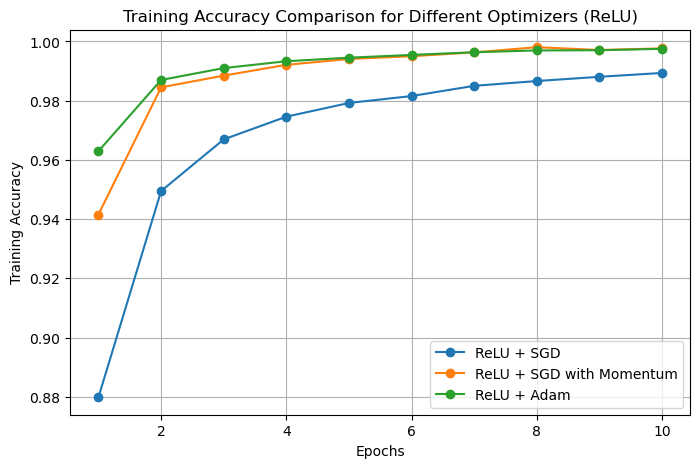

In [22]:
import matplotlib.pyplot as plt

epochs = range(1, len(acc_sgd) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, acc_sgd, label="ReLU + SGD", marker='o')
plt.plot(epochs, acc_mom, label="ReLU + SGD with Momentum", marker='o')
plt.plot(epochs, acc_adam, label="ReLU + Adam", marker='o')

plt.xlabel("Epochs")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Comparison for Different Optimizers (ReLU)")
plt.legend()
plt.grid(True)

plt.show()


The training accuracy curves show that Adam converges significantly faster than SGD and SGD with momentum. SGD exhibits a slow and steady increase in accuracy, while momentum improves convergence speed by reducing oscillations. Adam achieves higher accuracy in fewer epochs due to its adaptive learning rate mechanism, making it the most efficient optimizer among the three.

# Task 3: BN & Dropout Experiments

# WITHOUT Batch normalization and drop out layer

In [23]:
model = CNN(nn.ReLU(), use_bn=False, dropout=0.0).to(device)  # 🔥 move model to GPU
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

loss1, acc1 = train_model(
    model,
    optimizer,
    criterion,
    epochs=10
)

test1 = test_model(model)

print("Test Accuracy (No BN, Dropout=0.0):", test1)


Epoch 1/10 | Loss: 0.1172 | Acc: 96.42%
Epoch 2/10 | Loss: 0.0371 | Acc: 98.83%
Epoch 3/10 | Loss: 0.0233 | Acc: 99.25%
Epoch 4/10 | Loss: 0.0150 | Acc: 99.50%
Epoch 5/10 | Loss: 0.0120 | Acc: 99.60%
Epoch 6/10 | Loss: 0.0093 | Acc: 99.68%
Epoch 7/10 | Loss: 0.0075 | Acc: 99.75%
Epoch 8/10 | Loss: 0.0071 | Acc: 99.77%
Epoch 9/10 | Loss: 0.0049 | Acc: 99.85%
Epoch 10/10 | Loss: 0.0051 | Acc: 99.83%
Test Accuracy (No BN, Dropout=0.0): 0.9867


# Without BN, drop out layer=0.1

In [24]:
model = CNN(nn.ReLU(), use_bn=False, dropout=0.1).to(device)  # 🔥 move model to GPU
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

loss2, acc2 = train_model(
    model,
    optimizer,
    criterion,
    epochs=10
)

test2 = test_model(model)

print("Test Accuracy (No BN, Dropout=0.1):", test2)


Epoch 1/10 | Loss: 0.1185 | Acc: 96.42%
Epoch 2/10 | Loss: 0.0381 | Acc: 98.80%
Epoch 3/10 | Loss: 0.0240 | Acc: 99.23%
Epoch 4/10 | Loss: 0.0170 | Acc: 99.44%
Epoch 5/10 | Loss: 0.0130 | Acc: 99.57%
Epoch 6/10 | Loss: 0.0103 | Acc: 99.65%
Epoch 7/10 | Loss: 0.0092 | Acc: 99.66%
Epoch 8/10 | Loss: 0.0076 | Acc: 99.75%
Epoch 9/10 | Loss: 0.0062 | Acc: 99.81%
Epoch 10/10 | Loss: 0.0059 | Acc: 99.80%
Test Accuracy (No BN, Dropout=0.1): 0.9899


# With BN, drop out layer=0.25

In [25]:
model = CNN(nn.ReLU(), use_bn=True, dropout=0.25).to(device)  # 🔥 move model to GPU
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

loss3, acc3 = train_model(
    model,
    optimizer,
    criterion,
    epochs=10
)

test3 = test_model(model)

print("Test Accuracy (With BN, Dropout=0.25):", test3)


Epoch 1/10 | Loss: 0.1151 | Acc: 97.09%
Epoch 2/10 | Loss: 0.0406 | Acc: 98.80%
Epoch 3/10 | Loss: 0.0281 | Acc: 99.13%
Epoch 4/10 | Loss: 0.0209 | Acc: 99.32%
Epoch 5/10 | Loss: 0.0170 | Acc: 99.48%
Epoch 6/10 | Loss: 0.0141 | Acc: 99.51%
Epoch 7/10 | Loss: 0.0106 | Acc: 99.68%
Epoch 8/10 | Loss: 0.0102 | Acc: 99.67%
Epoch 9/10 | Loss: 0.0079 | Acc: 99.73%
Epoch 10/10 | Loss: 0.0076 | Acc: 99.74%
Test Accuracy (With BN, Dropout=0.25): 0.9907


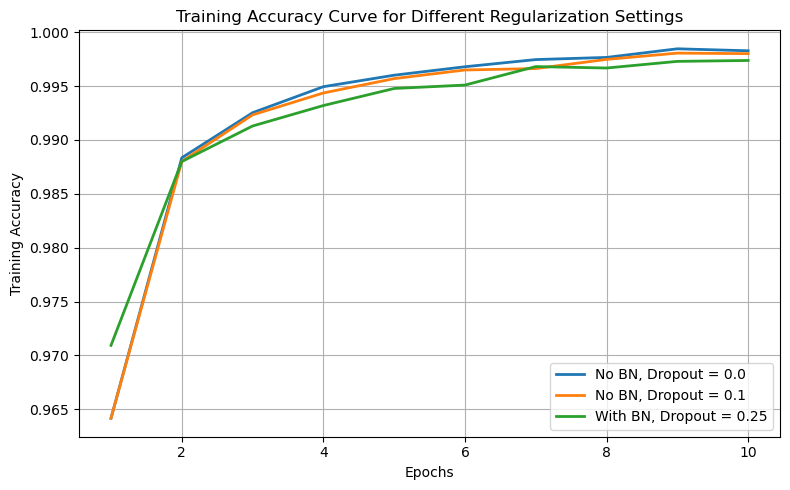

In [26]:
import matplotlib.pyplot as plt

epochs = range(1, len(acc1) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, acc1, label="No BN, Dropout = 0.0", linewidth=2)
plt.plot(epochs, acc2, label="No BN, Dropout = 0.1", linewidth=2)
plt.plot(epochs, acc3, label="With BN, Dropout = 0.25", linewidth=2)

plt.xlabel("Epochs")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Curve for Different Regularization Settings")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Configuration	Training Accuracy	Test Accuracy	Observation
    No BN, No Dropout	99.83%	98.67%	Slight overfitting
    No BN, Dropout = 0.1	99.80%	98.99%	Better generalization
    BN + Dropout = 0.25	99.74%	99.07%	Best generalization

# Without Batch Normalization and Dropout

    Observed Results:
    
    Training Accuracy: 99.83%
    
    Test Accuracy: 98.67%
    
    Analysis:
    
    In this configuration, the model achieves very high training accuracy, indicating that it fits the training data extremely well. However, the test accuracy is comparatively lower than the training accuracy, showing a small generalization gap.
    
    Since there is no regularization, the model has full capacity to memorize training patterns, which can lead to mild overfitting. This behavior is expected for MNIST, which is a relatively simple dataset.

# Without Batch Normalization, Dropout = 0.1
    
    Observed Results:
    
    Training Accuracy: 99.80%
    
    Test Accuracy: 98.99%
    
    Analysis:
    
    Introducing a small dropout rate helps reduce overfitting by randomly deactivating neurons during training. As a result, the model becomes more robust and generalizes better to unseen data.

# With Batch Normalization and Dropout = 0.25

    Observed Results:
    
    Training Accuracy: 99.74%
    
    Test Accuracy: 99.07% (highest)
    
    Analysis:
    
    This configuration achieves the best test accuracy among all three experiments. Batch Normalization stabilizes training by normalizing layer activations, which allows for smoother and faster convergence. Dropout further regularizes the network by reducing co-adaptation of neurons.
    
    Although the training accuracy is slightly lower than the previous cases, the generalization performance is the best, which is the primary goal in machine learning.

# comparison table

In [7]:
import pandas as pd

results1 = [
    {"Experiment": 1, "Activation": "Sigmoid", "Optimizer": "SGD",  "Epochs": 10, "Final Accuracy": 91.69},
    {"Experiment": 2, "Activation": "Tanh",    "Optimizer": "SGD",  "Epochs": 10, "Final Accuracy": 97.98},
    {"Experiment": 3, "Activation": "ReLU",    "Optimizer": "SGD", "Epochs": 10, "Final Accuracy": 98.5},
    {"Experiment": 4, "Activation": "ReLU", "Optimizer": "SGD-momentum",  "Epochs": 10, "Final Accuracy": 99.01},
    {"Experiment": 5, "Activation": "ReLU",    "Optimizer": "Adam",  "Epochs": 10, "Final Accuracy": 99}
    
    
]

df1 = pd.DataFrame(results1)


results2 = [
    {"Experiment": 1, "Activation": "ReLU",    "Optimizer": "Adam", "Batch Normalization":"NO","Dropout" : "0", "Epochs": 10, "Final Accuracy": 98.67},
    
    {"Experiment": 2, "Activation": "ReLU",    "Optimizer": "Adam", "Batch Normalization":"NO","Dropout" : "0.1", "Epochs": 10, "Final Accuracy": 98.99},
    
    {"Experiment": 3, "Activation": "ReLU",    "Optimizer": "Adam",  "Batch Normalization":"YES","Dropout" : "0.25","Epochs": 10, "Final Accuracy": 99.07}
    
    
]

df2 = pd.DataFrame(results2)

In [8]:
df1

,Experiment,Activation,Optimizer,Epochs,Final Accuracy
0,1,Sigmoid,SGD,10,91.69
1,2,Tanh,SGD,10,97.98
2,3,ReLU,SGD,10,98.50
3,4,ReLU,SGD-momentum,10,99.01
4,5,ReLU,Adam,10,99.00


In [9]:
df2

,Experiment,Activation,Optimizer,Batch Normalization,Dropout,Epochs,Final Accuracy
0,1,ReLU,Adam,NO,0,10,98.67
1,2,ReLU,Adam,NO,0.1,10,98.99
2,3,ReLU,Adam,YES,0.25,10,99.07
